100%|██████████| 805/805 [00:05<00:00, 141.93it/s]


Loading FEM graph dataset...
Build Complete FEM graph dataset...


100%|██████████| 805/805 [00:05<00:00, 145.02it/s]


Loading FEM graph dataset...
Build Complete FEM graph dataset...
[LOAD[START] VAE param


102it [00:00, 589282.38it/s]


[LOAD][COMPLETE] VAE param
[TRAIN] epoch:  1 batch:  0 step:  50 loss:  0.7977818846702576
vmin -0.18492624 vmax -0.18435517


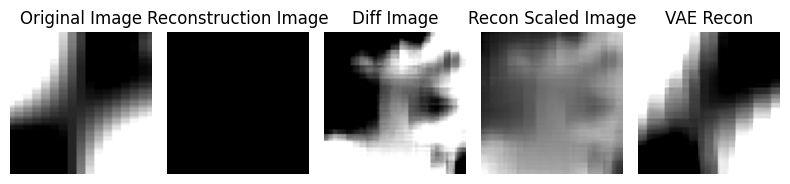

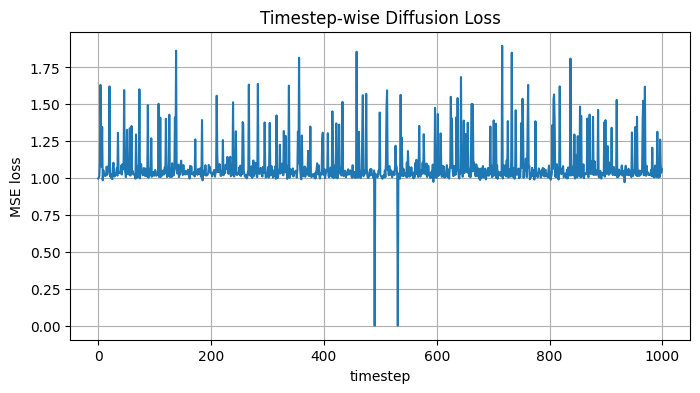

[TRAIN] epoch:  1 batch:  1 step:  100 loss:  0.7978423833847046
vmin -0.18519594 vmax -0.18402117


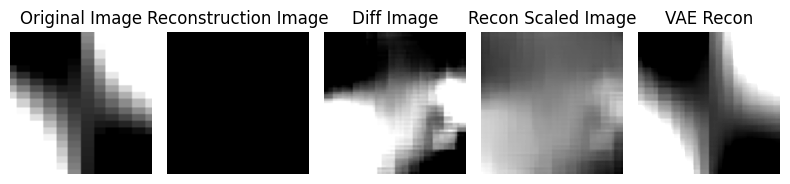

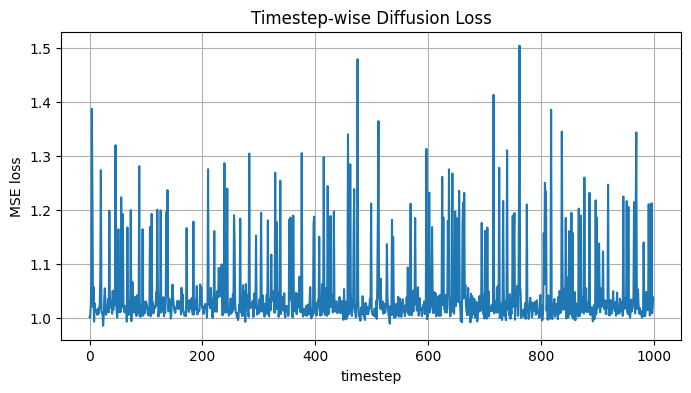

[TRAIN] epoch:  1 batch:  2 step:  150 loss:  0.7960513234138489
vmin -0.1964907 vmax -0.17240985


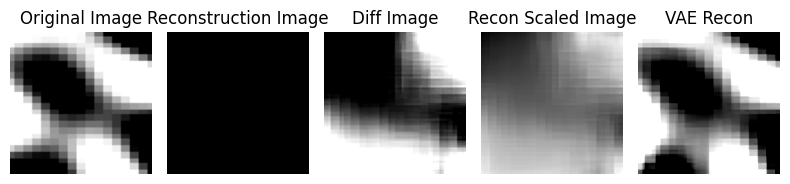

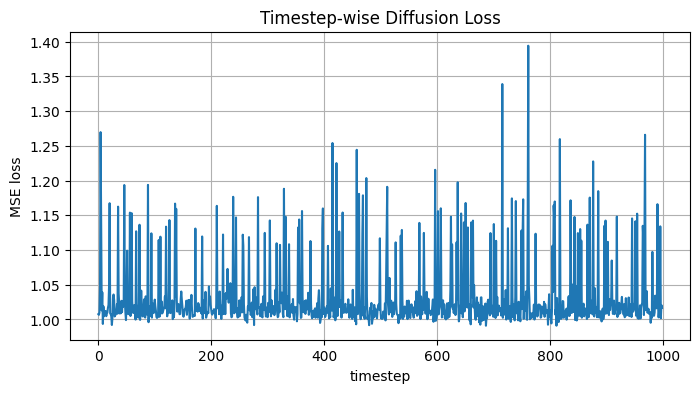

[TRAIN] epoch:  1 batch:  3 step:  200 loss:  0.7969872951507568
vmin -0.18474662 vmax -0.1846237


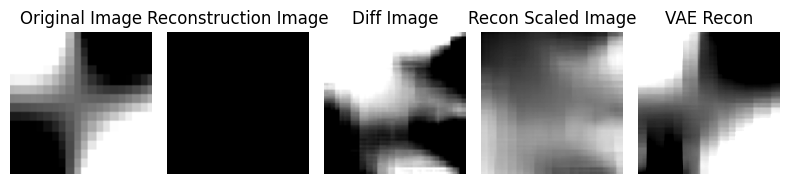

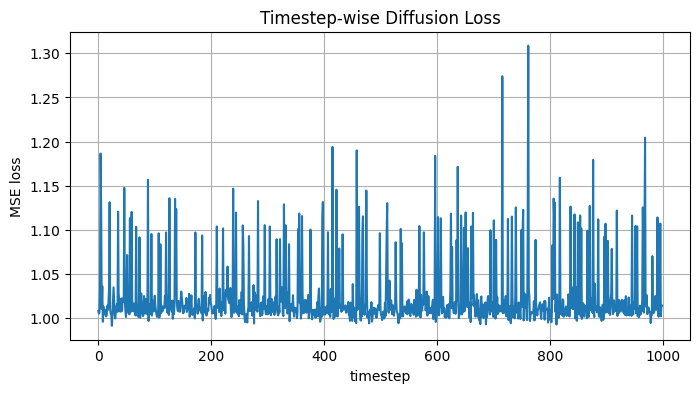

[TRAIN] epoch:  1 batch:  3 step:  250 loss:  0.7956462502479553
vmin -0.18471642 vmax -0.18459074


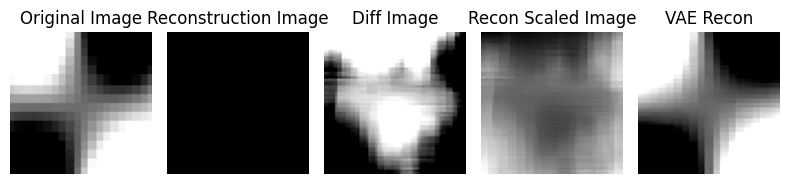

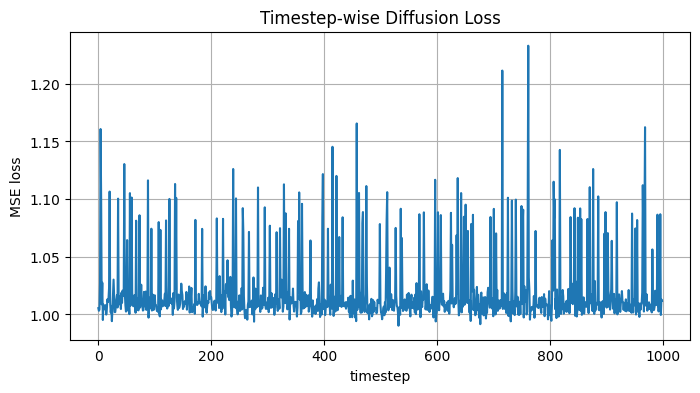

[TRAIN] epoch:  1 batch:  4 step:  300 loss:  0.7965465188026428
vmin -0.1854078 vmax -0.18364896


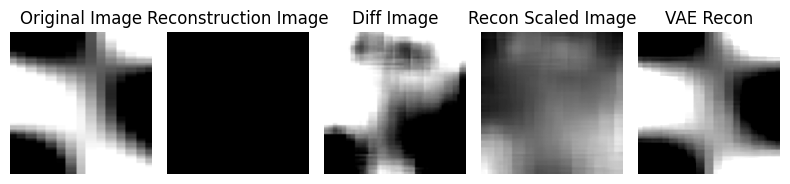

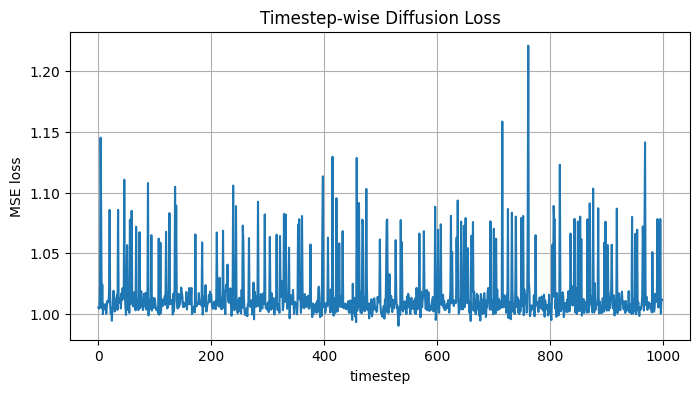

[TRAIN] epoch:  1 batch:  5 step:  350 loss:  0.798396110534668
vmin -0.18475747 vmax -0.18437052


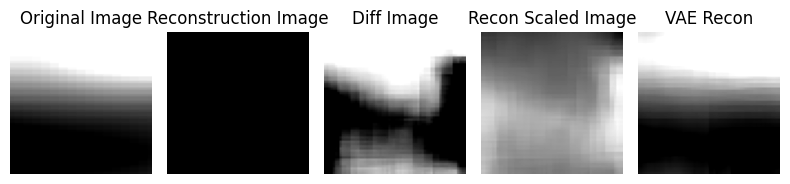

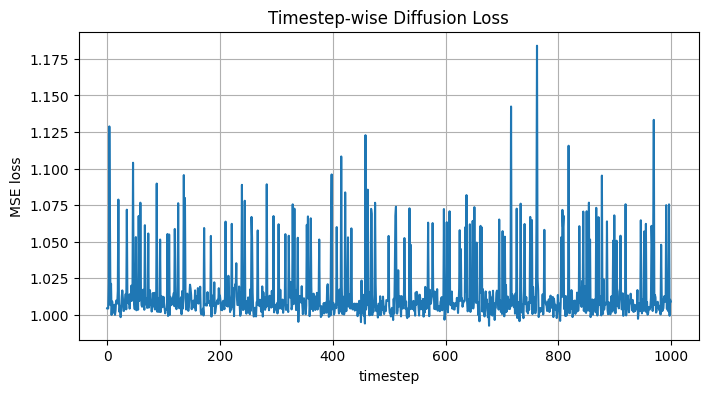

[VALID] epoch:  1 batch:  0 step:  50 loss:  0.8022407293319702
vmin -0.1846609 vmax -0.18454589


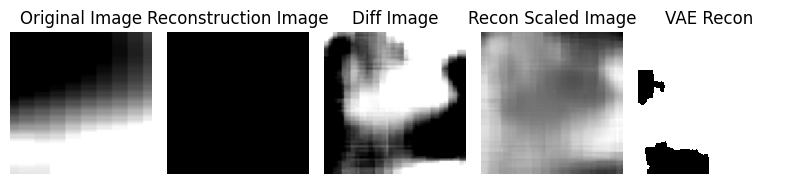

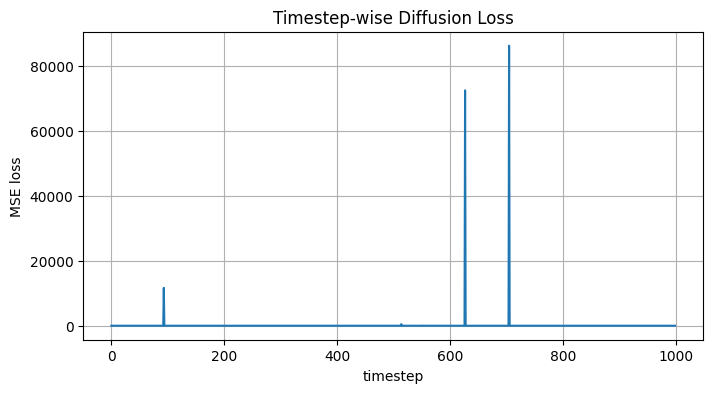

Epoch 2/1000, Train Loss: 8.006525e-01, Val Loss: 1.568991e+00


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn.functional as F
from fem_dataset_to_image_full_mesh_diffusion import FemImageDataset as MeshDataset
from fem_model import TinyLatentDiffusion,DDPMScheduler,ScalingVAE4,reparameterize
import json
from torch.utils.data import DataLoader
from utils import EarlyStopping
import gc
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
from tqdm import tqdm
import torch
from collections import defaultdict

class TimeLossTracker:
    def __init__(self, T):
        self.T = T
        self.loss_sum = torch.zeros(T)
        self.count = torch.zeros(T)

    def update(self, t, loss):
        """
        t: (B,) int64
        loss: (B,) or scalar
        """
        if loss.ndim == 0:
            loss = loss.repeat(len(t))

        for ti, li in zip(t, loss):
            self.loss_sum[ti] += li.detach().cpu()
            self.count[ti] += 1

    def mean(self):
        return self.loss_sum / (self.count + 1e-8)


early_stopping = EarlyStopping(
    patience=50,     # FEM/GNN은 15~30 권장
    min_delta=1e-6,  # loss 스케일에 맞게
    mode="min"
)
def collate_flatten(batch): 
    images, conds = [], [] 
    batch_size=len(batch) 
    step_num_in_batch=len(batch[0]["image"]) 
    idxs=[] 
    for i in range(batch_size): 
        idx = torch.randperm(len(batch[0]["image"])) 
        idxs.append(idx) 
        # print(batch[i]['min_max'])
    idxs=np.array(idxs).T 

    for i in range(step_num_in_batch): 
        batch_images=[] 
        batch_conds=[] 
        for b_i,b in enumerate(batch): 
            id=idxs[i][b_i] 
            batch_images.append(b['image'][id]) 
            batch_conds.append(b['cond'][id]) 
        images.append(batch_images) 
        conds.append(batch_conds) 
    return { "image": images, "cond": conds, }

def draw(data1,data2,data3,data4,model_param): 
    stride=1 
    clip_q=(0.25,0.75) 
    cmap="jet" 
    ql, qh = np.quantile(data1.cpu().detach().numpy(), clip_q) 
    Uf1_clip = np.clip(data1.cpu().detach().numpy(), ql, qh) 
    ql, qh = np.quantile(data2.cpu().detach().numpy(), clip_q) 
    Uf2_clip = np.clip(data2.cpu().detach().numpy(), ql, qh) 
    print('vmin',Uf1_clip.min(),'vmax',Uf1_clip.max())
    plt.figure(figsize=(8, 4)) 
    plt.subplot(1, 5, 1) 
    plt.imshow(Uf1_clip, cmap="gray",vmin=Uf1_clip.min(),vmax=Uf1_clip.max()) 
    plt.title("Original Image") 
    plt.axis("off") 
    plt.subplot(1, 5, 2) 
    plt.imshow(Uf2_clip, cmap="gray",vmin=Uf1_clip.min(),vmax=Uf1_clip.max())
    plt.title("Reconstruction Image") 
    plt.axis("off") 
    plt.subplot(1, 5, 3) 
    plt.imshow(np.abs(Uf1_clip-Uf2_clip), cmap="gray")
    plt.title("Diff Image") 
    plt.axis("off")
    plt.subplot(1, 5, 4) 
    plt.imshow(data3.cpu().detach().numpy(), cmap="gray")
    plt.title("Recon Scaled Image") 
    plt.axis("off")
    plt.subplot(1, 5, 5) 
    plt.imshow(data4.cpu().detach().numpy(), cmap="gray",vmin=Uf1_clip.min(),vmax=Uf1_clip.max())
    plt.title("VAE Recon") 
    plt.axis("off")
    plt.tight_layout() 
    plt.show()

def charbonnier_loss(pred: torch.Tensor,
                    target: torch.Tensor,
                    eps: float = 1e-8,
                    reduction: str = "mean") -> torch.Tensor:
    """
    Charbonnier loss (a smooth L1 / pseudo-Huber variant):
        L = sqrt((pred - target)^2 + eps^2)

    Args:
        pred, target: same shape tensors
        eps: smoothing term (bigger -> more L1-like near 0)
        reduction: "mean" | "sum" | "none"

    Returns:
        loss tensor (scalar if reduced)
    """
    if pred.shape != target.shape:
        raise ValueError(f"Shape mismatch: pred{pred.shape} vs target{target.shape}")

    diff = pred - target
    loss = torch.sqrt(diff * diff + eps * eps)
    if reduction == "per_sample":
        loss_per_sample = ((diff) ** 2).mean(dim=(1,2,3))
        return loss_per_sample
    if reduction == "mean":
        return loss.mean()
    if reduction == "sum":
        return loss.sum()
    if reduction == "none":
        return loss

    raise ValueError("reduction must be one of {'mean','sum','none'}")

def diffusion_loss_ddpm(model: nn.Module, x0: torch.Tensor, cond: torch.Tensor, sched: DDPMScheduler, tracker:TimeLossTracker):
    """
    x0:   (B,C,4,4) clean latent
    cond: (B,Z)
    """
    device = x0.device
    B = x0.size(0)

    t = torch.randint(0, sched.T, (B,), device=device, dtype=torch.long)
    noise = torch.randn_like(x0)
    x_t = sched.q_sample(x0, t, noise)
    v_tgt = sched.v_target(x0, noise, t)
    v_pred = model(x_t, t, cond)
    loss_per_sample=charbonnier_loss(v_pred, v_tgt,reduction='per_sample')
    tracker.update(t, loss_per_sample)
    return charbonnier_loss(v_pred, v_tgt)

def drawTimeLoss(tracker):
    time_loss=tracker.mean()
    plt.figure(figsize=(8,4))
    plt.plot(time_loss.numpy())
    plt.xlabel("timestep")
    plt.ylabel("MSE loss")
    plt.title("Timestep-wise Diffusion Loss")
    plt.grid()
    plt.show()

def train_one_epoch(model, loader, device, opt, model_param,epoch,VAE_model,sched,tracker): 
    model.train() 
    total = 0.0 
    count=0 
    for i, batch in enumerate(loader): 
        imags=batch['image'] 
        conds=batch['cond'] 
        for b in range(len(imags)): 
            s_batch = {'image':torch.stack(imags[b]).to(device),'cond':torch.Tensor(np.array(conds[b])).to(device)} 
            
            mean = s_batch['image'].mean(dim=(1,2,3), keepdim=True).detach() 
            std = s_batch['image'].std(dim=(1,2,3), keepdim=True).detach() 
            x_norm=(s_batch['image']-mean)/std 
            mu, logvar = VAE_model.encoder(x_norm)
            mean=VAE_model.norm_mean(mean)
            std=VAE_model.norm_std(std)
            z = reparameterize(mu, logvar) 
            B,C,X,Y=z.shape 
            z = torch.cat([z, mean.expand(B,1,X,Y), std.expand(B,1,X,Y)], dim=1) # [B, Z+2] 
            loss = diffusion_loss_ddpm(model, z, s_batch['cond'], sched,tracker) 
            opt.zero_grad() 
            loss.backward() 
            opt.step() 
            total += float(loss.item())
            count+=1 
            if count % 50 == 0: 
                print('[TRAIN] epoch: ',epoch,'batch: ',i,'step: ',count,'loss: ',float(loss.item()),) 
                origin_image=torch.stack(imags[b])[0,:][(model_param['dataset_in_channels']-1)//2] 
                _ , C, H, W =z.shape
                x0_generated = sched.p_sample_loop_v(
                                model=model,
                                shape=(1, C, H, W),
                                cond=s_batch['cond'][0,:].unsqueeze(0),
                                device=device,
                                return_all=False)
                scaled_image,iamge  = VAE_model.decoder(x0_generated)
                _,vae_iamge  = VAE_model.decoder(z)
                pred_image=iamge[0,:][(model_param['dataset_in_channels']-1)//2].cpu()
                draw(origin_image,pred_image,scaled_image[0,:][(model_param['dataset_in_channels']-1)//2],vae_iamge[0,:][(model_param['dataset_in_channels']-1)//2],model_param) 
                drawTimeLoss(tracker)
        del batch 
        gc.collect() 
    return total / max(1, count)
@torch.no_grad()
def eval_one_epoch(model, loader, device,  model_param,epoch,VAE_model,sched,tracker):
    model.eval()
    total = 0.0 
    count=0 
    for i, batch in enumerate(loader): 
        imags=batch['image'] 
        conds=batch['cond'] 
        for b in range(len(imags)): 
            s_batch = {'image':torch.stack(imags[b]).to(device),'cond':torch.Tensor(np.array(conds[b])).to(device)} 
            mean = s_batch['image'].mean(dim=(1,2,3), keepdim=True).detach() 
            std = s_batch['image'].std(dim=(1,2,3), keepdim=True).detach()
            x_norm=(s_batch['image']-mean)/std 
            mean=VAE_model.norm_mean(mean)
            std=VAE_model.norm_std(std)
            mu, logvar = VAE_model.encoder(x_norm) 
            z = reparameterize(mu, logvar) 
            B,C,X,Y=z.shape 
            z = torch.cat([z, mean.expand(B,1,X,Y), std.expand(B,1,X,Y)], dim=1) # [B, Z+2] 
            loss = diffusion_loss_ddpm(model, z, s_batch['cond'], sched,tracker) 
            total += float(loss.item())
            count+=1 
            if count % 50 == 0: 
                print('[VALID] epoch: ',epoch,'batch: ',i,'step: ',count,'loss: ',float(loss.item()),) 
                origin_image=torch.stack(imags[b])[0,:][(model_param['dataset_in_channels']-1)//2] 
                _ , C, H, W =z.shape
                x0_generated = sched.p_sample_loop_v(
                                model=model,
                                shape=(1, C, H, W),
                                cond=s_batch['cond'][0,:].unsqueeze(0),
                                device=device,
                                return_all=False
                )
                scaled_image,iamge  = VAE_model.decoder(x0_generated)
                _,vae_iamge  = VAE_model.decoder(z)
                pred_image=iamge[0,:][(model_param['dataset_in_channels']-1)//2].cpu()
                draw(origin_image,pred_image,scaled_image[0,:][(model_param['dataset_in_channels']-1)//2],vae_iamge[0,:][(model_param['dataset_in_channels']-1)//2],model_param) 
                drawTimeLoss(tracker)
        del batch 
        gc.collect() 
    return total / max(1, count)

def main():
    root = "./data"
    if torch.cuda.is_available() :
        device='cuda'
    elif torch.backends.mps.is_available() :
        device='mps'
    else :
        device='cpu'

    model_param={
                'dataset_in_channels':3,  
                'in_channels':256, 
                'out_channels':3,
                'GRID':64,
                'loss_scale':1.0,
                'learning_rate':5e-3,
                'num_epochs':1000,
                'base':256,
                'num_cond_tokens':128,
                'token_dim':128,
                'time_dim':128,
                'batch_size':128,
                'T':1000 } 
    with open(os.path.join( "model_param_diffustion_vae4_2_early.json"), "r", encoding="utf-8") as f:
        VAE_model_param = json.load(f)

    train_ds = MeshDataset(root_dir=root,type='train',GRID=model_param['GRID'],in_channels=model_param['dataset_in_channels']) 
    val_ds= MeshDataset(root_dir=root,type='valid',GRID=model_param['GRID'],in_channels=model_param['dataset_in_channels']) 

    train_loader = DataLoader(train_ds, batch_size=model_param['batch_size'], shuffle=True, collate_fn=collate_flatten) 
    val_loader = DataLoader(val_ds, batch_size=model_param['batch_size'], shuffle=False, collate_fn=collate_flatten) 
    example = train_ds[0] 
    model_param['cond_dim']=len(example['cond'][0])
    model_param['dataset_scale_info']=train_ds.scale_info 

    
    VAE_model = ScalingVAE4( in_channels=VAE_model_param['in_channels'], 
                latent_dim=VAE_model_param['latent_dim'], 
                base=VAE_model_param['base'],
                depth=VAE_model_param['depth'] ).to(device)
    print('[LOAD[START] VAE param')
    ckpt = torch.load("mesh_invariant_diffustion_vae4_2_early_epoch019.pt", map_location=device)
    VAE_model.load_state_dict(ckpt)
    
    for p in tqdm(VAE_model.parameters()):
        p.requires_grad = False
    print('[LOAD][COMPLETE] VAE param')
    
    model = TinyLatentDiffusion(
        in_channels=VAE_model_param['latent_dim']+2,
        out_channels=VAE_model_param['in_channels'],
        base_channels=model_param['base'],
        cond_dim=model_param['cond_dim'],
        num_cond_tokens=model_param['num_cond_tokens'],  # 의미 단위로 늘릴수록 cross-attn 효과 커짐
        token_dim=model_param['token_dim'],
        time_dim=model_param['time_dim'],
    ).to(device)
    ckpt = torch.load("mesh_invariant_stable_diffustion_ver3_epoch000.pt", map_location=device)
    model.load_state_dict(ckpt)
    sched = DDPMScheduler(T=model_param['T']).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=model_param['learning_rate'], weight_decay=1e-6)
    loss_dict={}
    for epoch in range(model_param['num_epochs']):  
        epoch=epoch+1    
        tracker = TimeLossTracker(model_param['T'])
        train_loss = train_one_epoch(model, train_loader, device, optimizer,model_param,epoch,VAE_model,sched,tracker)
        val_loss = eval_one_epoch(model, val_loader, device,model_param,epoch,VAE_model,sched,tracker)
        loss_dict[epoch] = {'train_loss':train_loss, 'val_loss':val_loss}   
        print(f"Epoch {epoch+1}/{model_param['num_epochs']}, Train Loss: {train_loss:.6e}, Val Loss: {val_loss:.6e}")  
        improved = early_stopping.step(val_loss)
        with open(f"loss_history_stable_diffustion_ver3.json", "w", encoding="utf-8") as f:
            json.dump(loss_dict, f, indent=2)
        if improved:
            best_val = val_loss
            # print(eval_one_epoch_sample_mse(model, val_loader, device, sched))
            torch.save(model.state_dict(), f"mesh_invariant_stable_diffustion_ver3_early_epoch{str(epoch).zfill(3)}.pt")  # best만 저장

            with open(f"model_param_stable_diffustion_ver3_early.json", "w", encoding="utf-8") as f:
                json.dump(model_param, f, indent=2)
        if early_stopping.should_stop:
            print(
                f"\n Early stopping at epoch {epoch} "
                f"(best val = {best_val:.6e})"
            )
            break
        if epoch%10==0:
            torch.save(model.state_dict(), f"mesh_invariant_stable_diffustion_ver3_epoch{str(epoch).zfill(3)}.pt")
    torch.save(model.state_dict(), "mesh_invariant_stable_diffustion_ver3.pt")
    with open(f"model_param_stable_diffustion_ver3.json", "w", encoding="utf-8") as f:
        json.dump(model_param, f, indent=2) 

if __name__ == "__main__":
    main()